# Logistic Regression

In [252]:
import sys 
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [253]:
%reload_ext autoreload
%autoreload 2
# misc imports
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter
import pandas as pd

# sklearn imports
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.metrics import confusion_matrix

# PyTorch imports
import torch
import torch.nn as nn

# own imports
from models.logistic_regression import LogisticRegression
from utils.plots import (
    plot_confusion_matrix,
    plot_difference_loss,
    plot_decision_boundary,
)
from utils.torch import TorchModelWrapper
from metrics.classification import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from utils.tests import (
    parameter_sweep_classification,
    learning_rate_threshold_sweep
)
from utils.timings import benchmark_model

## Dataset

### Generation

In [254]:
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    class_sep=1.5,
    random_state=42,
)

### Split and Scaling

In [255]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Plotting

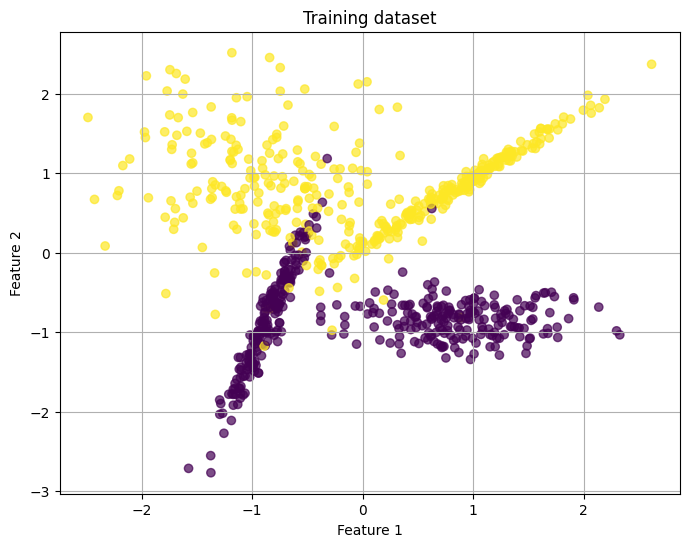

In [256]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    alpha=0.7,
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training dataset")
plt.grid(True)

plt.show()

## Comparison with `sklearn` and `PyTorch` models

### Scratch Model

In [257]:
scratch_model = LogisticRegression(lr=0.1, n_iters=1000)

start = perf_counter()
scratch_model.fit(X_train_scaled, y_train)
scratch_fit_time = perf_counter() - start

start = perf_counter()
scratch_preds = scratch_model.predict(X_test_scaled)
scratch_predict_time = perf_counter() - start

scratch_proba = scratch_model.predict_proba(X_test_scaled)

### `Sklearn` Model

In [258]:
sklearn_model = SklearnLogisticRegression()

start = perf_counter()
sklearn_model.fit(X_train_scaled, y_train)
sklearn_fit_time = perf_counter() - start

start = perf_counter()
sklearn_preds = sklearn_model.predict(X_test_scaled)
sklearn_predict_time = perf_counter() - start

sklearn_proba = sklearn_model.predict_proba(X_test_scaled)[:, 1]

### `PyTorch` Model

In [259]:
def predict_fn_lgr(output):
    #output = torch_model(X_test_tensor)
    torch_proba = torch.sigmoid(output).numpy().ravel()
    return (torch_proba >= 0.5).astype(int)

def predict_proba_fn_lgr(output):
    #output = torch_model(X_test_tensor)
    torch_proba = torch.sigmoid(output).numpy().ravel()
    return torch_proba

torch_model = nn.Linear(X_train_scaled.shape[1], 1)

torch_wrapper = TorchModelWrapper(
    model=torch_model,
    loss_fn=nn.BCEWithLogitsLoss(),
    optimizer_cls=torch.optim.SGD,
    lr=0.1,
    n_iters=1000,
    predict_fn=predict_fn_lgr,
    predict_proba_fn=predict_proba_fn_lgr,
    seed=42,
    zero_weights=True
)

start = perf_counter()
torch_wrapper.fit(X_train_scaled, y_train)
torch_fit_time = perf_counter() - start


start = perf_counter()
torch_preds = torch_wrapper.predict(X_test_scaled)
torch_predict_time = perf_counter() - start

torch_proba = torch_wrapper.predict_proba(X_test_scaled)

### Results

In [260]:
results = {
    "From scratch": {
        "Accuracy": accuracy_score(y_test, scratch_preds),
        "Precision": precision_score(y_test, scratch_preds),
        "Recall": recall_score(y_test, scratch_preds),
        "F1": f1_score(y_test, scratch_preds),
        "ROC AUC": roc_auc_score(y_test, scratch_proba),
    },
    "Scikit-learn": {
        "Accuracy": accuracy_score(y_test, sklearn_preds),
        "Precision": precision_score(y_test, sklearn_preds),
        "Recall": recall_score(y_test, sklearn_preds),
        "F1": f1_score(y_test, sklearn_preds),
        "ROC AUC": roc_auc_score(y_test, sklearn_proba),
    },
    "PyTorch": {
        "Accuracy": accuracy_score(y_test, torch_preds),
        "Precision": precision_score(y_test, torch_preds),
        "Recall": recall_score(y_test, torch_preds),
        "F1": f1_score(y_test, torch_preds),
        "ROC AUC": roc_auc_score(y_test, torch_proba),
    },
}

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1,ROC AUC
From scratch,0.93,0.93,0.93,0.93,0.9781
Scikit-learn,0.93,0.93,0.93,0.93,0.9779
PyTorch,0.93,0.93,0.93,0.93,0.9781


## Plots and Metrics

### Loss Curves

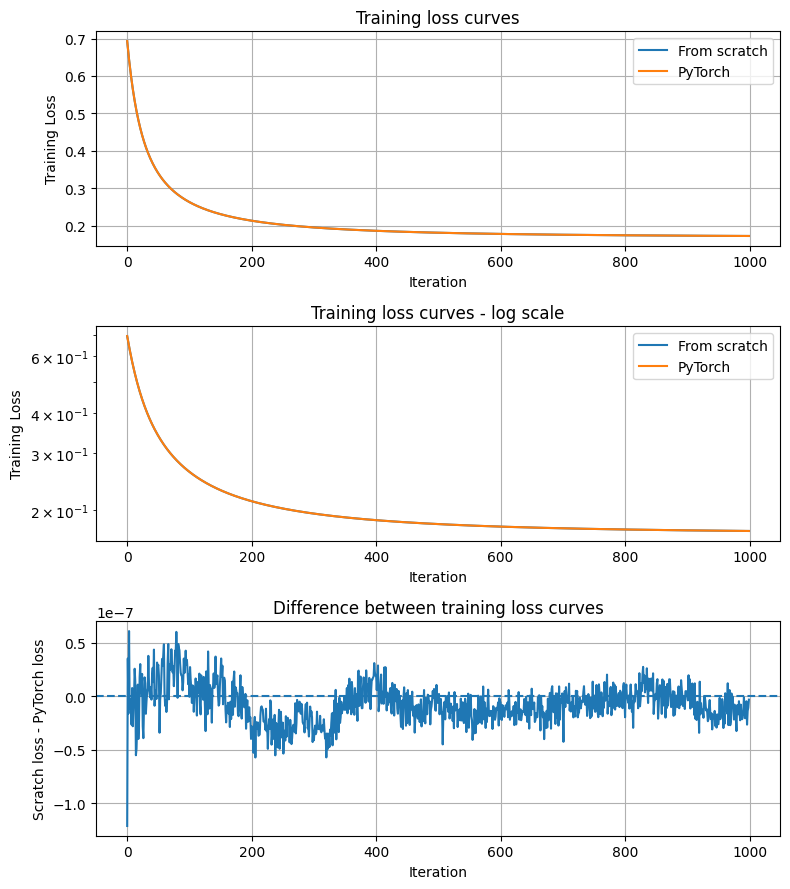

In [261]:
plot_difference_loss(scratch_model.loss_history, torch_wrapper.loss_history)

### Confusion Matrix
For this simple dataset, all models give the same results for the confusion matrix

In [262]:
cm_scratch = confusion_matrix(y_test, scratch_preds)
cm_sklearn = confusion_matrix(y_test, sklearn_preds)
cm_torch = confusion_matrix(y_test, torch_preds)

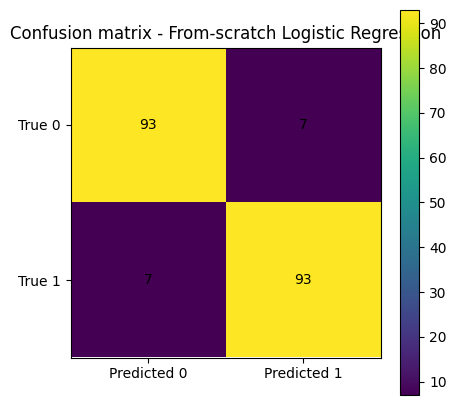

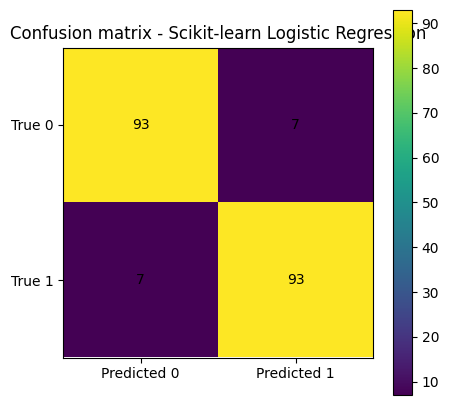

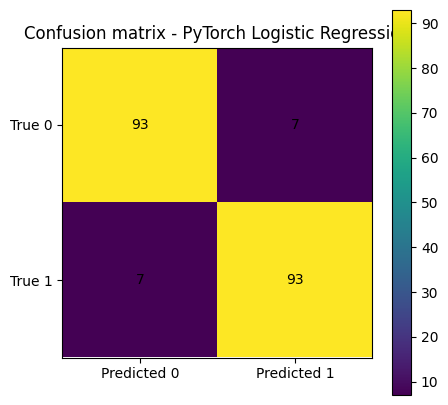

In [263]:
plot_confusion_matrix(
    cm_scratch,
    [0,1],
    "Confusion matrix - From-scratch Logistic Regression"
)

plot_confusion_matrix(
    cm_sklearn,
    [0,1],
    "Confusion matrix - Scikit-learn Logistic Regression"
)

plot_confusion_matrix(
    cm_torch,
    [0,1],
    "Confusion matrix - PyTorch Logistic Regression"
)

### Decision Boundary
The decision boundary shows which regions belong to which class according to the trained model, meaning that if a test sample falls in one region, it is assigned to the class belonging to that region.

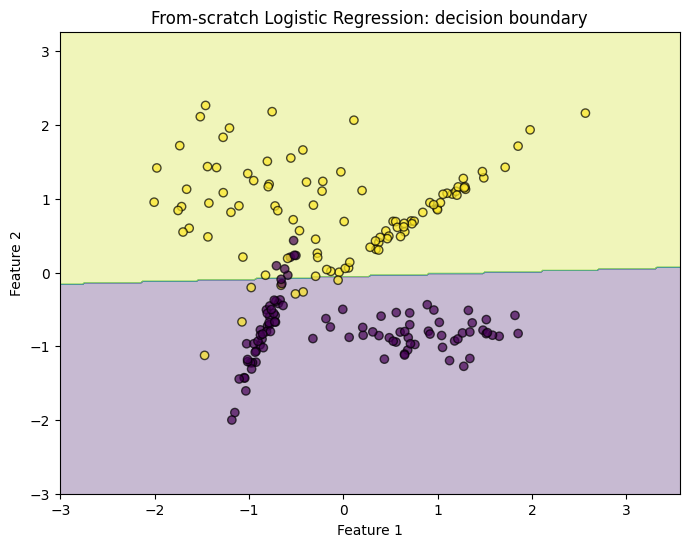

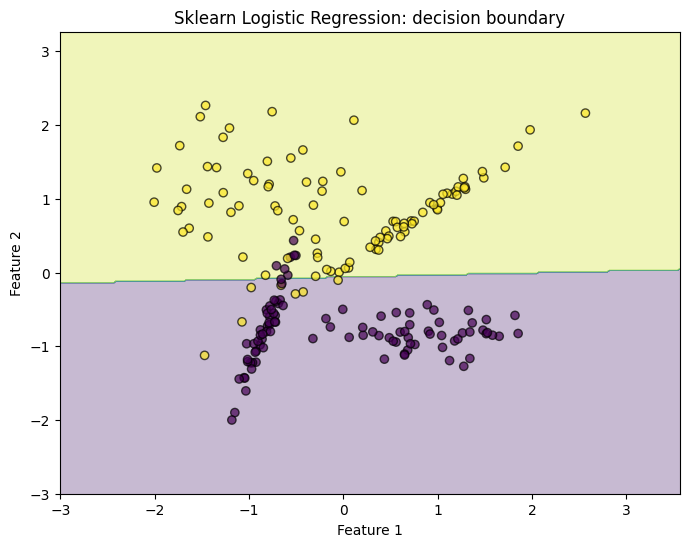

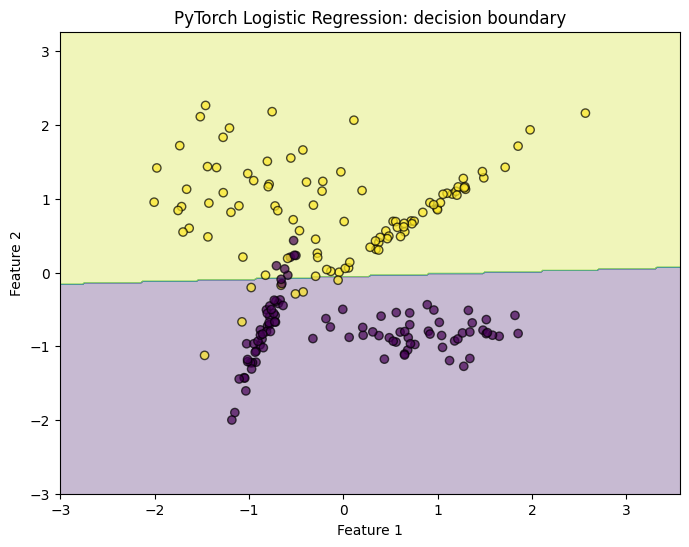

In [264]:
plot_decision_boundary(
    scratch_model,
    X_test_scaled,
    y_test,
    "From-scratch Logistic Regression: decision boundary"
)

plot_decision_boundary(
    sklearn_model,
    X_test_scaled,
    y_test,
    "Sklearn Logistic Regression: decision boundary"
)

plot_decision_boundary(
    torch_wrapper,
    X_test_scaled,
    y_test,
    "PyTorch Logistic Regression: decision boundary"
)

## Hyperparameter Sweeps

### Learning Rate

#### Accuracy
Looking at the accuracy vs. the learning rate, we can see that for certain values the accuracy is equal to $185/200=0.925$, while for others $186/200=0.3$. This depends from the fact that as the learning rate changes, the weights of the model also change slightly, but for such a small dataset, this is unlikely to flip a sample across the $0.5$ threshold. For certain values however, one extra sample becomes correct (from 185 to 186), leading to the jumps in the plot. This is one reason why accuracy alone is a poor optimization diagnostic.

#### ROC-AUC
The ROC-AUC vs. learning rate plot also shows an interesting trend, which is the combination of having a finite dataset, finite iterations, and very similar converged solutions for each learning rate. The main point is that *ROC-AUC depends only on ranking*, and not on exact probabilities, as it is a measurement of how likely a model is to classify a positive sample above a negative one.

Doing a learning rate sweep mostly changes the speed of convergence, and not which optimum is reached, that is the order in which the samples are ranked, because the logistic regression has a convex loss. This means that after 1000 iterations, most learning rates end up in nearly the same region of the parameter space, and the tiny fluctuations observable in the plot are probably due to 
- incomplete convergence for some lrs
- slight ranking changes near the decision boundary
- finite floating-point effects

and are negligible.

#### Final Considerations
Unlike the regression case, varying the learning rate in logistic regression mainly affected convergence speed rather than the final classifier quality. Since logistic regression optimizes a convex objective, many stable learning rates eventually converged to very similar solutions after enough iterations. Consequently, metrics such as accuracy and ROC AUC remained nearly constant across a broad range of learning rates.

In short, learning rate strongly affects optimization dynamics, but not necessarily the final optimum reached, especially in convex problems.

In [265]:
values = np.logspace(-4, 1, 50)
sweep_results, loss_curves = parameter_sweep_classification(
    model_cls=LogisticRegression, 
    param_grid={
        'lr': values
    }, 
    X_train=X_train_scaled, 
    y_train=y_train, 
    X_test=X_test_scaled, 
    y_test=y_test, 
    base_params={'n_iters':1000})

In [266]:
sweep_df = pd.DataFrame(sweep_results)
sweep_df.head(10)

,lr,n_iters,final_train_loss,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,fit_time,initial_train_loss,min_train_loss,stable,converged
0,0.000100,1000,0.676149,0.925,0.938144,0.91,0.923858,0.9781,0.096350,0.693147,0.676149,True,True
1,0.000126,1000,0.671788,0.925,0.938144,0.91,0.923858,0.9781,0.114423,0.693147,0.671788,True,True
2,0.000160,1000,0.666352,0.925,0.938144,0.91,0.923858,0.9781,0.122234,0.693147,0.666352,True,True
3,0.000202,1000,0.659606,0.925,0.938144,0.91,0.923858,0.9781,0.102786,0.693147,0.659606,True,True
4,0.000256,1000,0.651273,0.925,0.938144,0.91,0.923858,0.9781,0.095792,0.693147,0.651273,True,True
5,0.000324,1000,0.641046,0.925,0.938144,0.91,0.923858,0.9781,0.095323,0.693147,0.641046,True,True
6,0.000409,1000,0.628591,0.925,0.938144,0.91,0.923858,0.9781,0.090565,0.693147,0.628591,True,True
7,0.000518,1000,0.613571,0.925,0.938144,0.91,0.923858,0.9781,0.085443,0.693147,0.613571,True,True
8,0.000655,1000,0.595674,0.925,0.938144,0.91,0.923858,0.9781,0.091890,0.693147,0.595674,True,True
9,0.000829,1000,0.574666,0.925,0.938144,0.91,0.923858,0.9781,0.096266,0.693147,0.574666,True,True


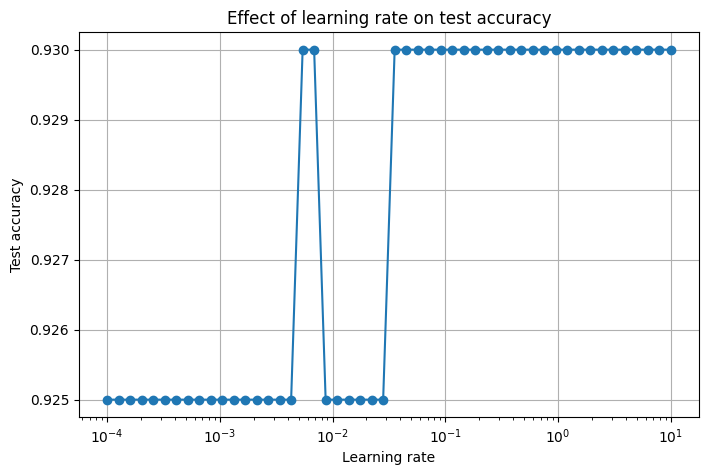

In [267]:
plt.figure(figsize=(8, 5))
plt.plot(sweep_df["lr"], sweep_df["test_accuracy"], marker="o")
plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("Test accuracy")
plt.title("Effect of learning rate on test accuracy")
plt.grid(True)
plt.show()

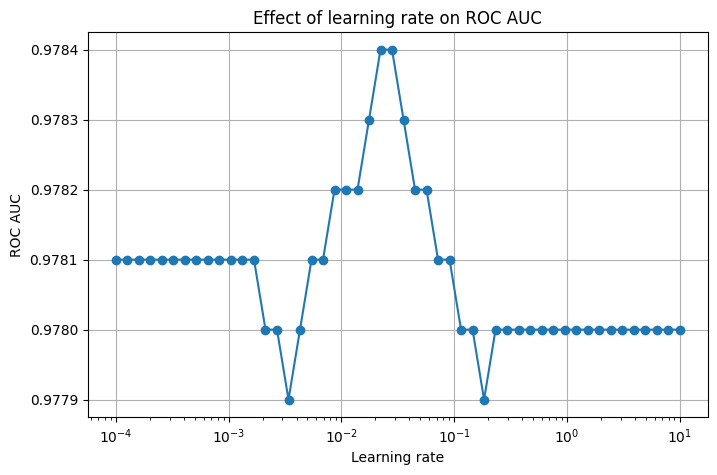

In [268]:
plt.figure(figsize=(8, 5))

plt.plot(sweep_df["lr"], sweep_df["test_roc_auc"], marker="o")

plt.xscale("log")

plt.xlabel("Learning rate")
plt.ylabel("ROC AUC")
plt.title("Effect of learning rate on ROC AUC")

plt.grid(True)
plt.show()

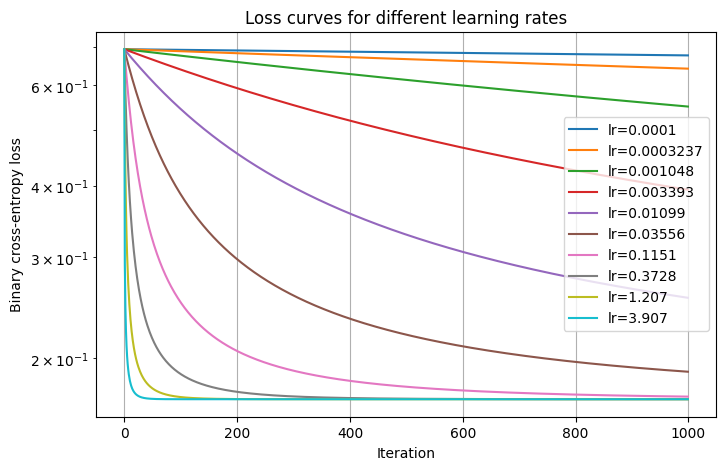

In [269]:
plt.figure(figsize=(8, 5))

for item in loss_curves[::5]:
    loss = np.asarray(item["loss"])

    valid_mask = np.isfinite(loss)

    plt.plot(
        np.arange(len(loss))[valid_mask],
        loss[valid_mask],
        label=f"lr={item['lr']:.4g}",
    )

plt.xlabel("Iteration")
plt.ylabel("Binary cross-entropy loss")
plt.title("Loss curves for different learning rates")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.show()

## Benchmark Timings

In [271]:
scratch_timing = benchmark_model(
    lambda: LogisticRegression(lr=0.01, n_iters=1000),
    X_train_scaled,
    y_train,
    X_test_scaled,
)

sklearn_timing = benchmark_model(
    lambda: SklearnLogisticRegression(),
    X_train_scaled,
    y_train,
    X_test_scaled,
)

pytorch_timing = benchmark_model(
    lambda: TorchModelWrapper(
    model=torch_model,
    loss_fn=nn.BCEWithLogitsLoss(),
    optimizer_cls=torch.optim.SGD,
    lr=0.01,
    n_iters=1000,
    predict_fn=predict_fn_lgr,
    predict_proba_fn=predict_proba_fn_lgr,
    seed=42
    ),
    X_train_scaled,
    y_train,
    X_test_scaled,
)

In [272]:
timing_df = pd.DataFrame({
    "From scratch": scratch_timing,
    "Scikit-learn": sklearn_timing,
    "PyTorch": pytorch_timing
}).T

timing_df

,fit_time_mean,fit_time_std,predict_time_mean,predict_time_std
From scratch,0.073297,0.008332,0.000036,0.000011
Scikit-learn,0.004472,0.001849,0.000266,0.000060
PyTorch,0.517869,0.110456,0.000209,0.000083


## Harder Dataset 

### Binary Classification
First I try with another dataset with two classes, but with more dimensions, redundant features, less class separation, and label noise.

In [273]:
X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_repeated=0,
    n_classes=2,
    class_sep=0.8,
    flip_y=0.05,
    random_state=42,
)

In [274]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Model Comparisons

In [275]:
# Scratch
scratch_model = LogisticRegression(lr=0.1, n_iters=1000)

start = perf_counter()
scratch_model.fit(X_train_scaled, y_train)
scratch_fit_time = perf_counter() - start

start = perf_counter()
scratch_preds = scratch_model.predict(X_test_scaled)
scratch_predict_time = perf_counter() - start

scratch_proba = scratch_model.predict_proba(X_test_scaled)

# Sklearn
sklearn_model = SklearnLogisticRegression()

start = perf_counter()
sklearn_model.fit(X_train_scaled, y_train)
sklearn_fit_time = perf_counter() - start

start = perf_counter()
sklearn_preds = sklearn_model.predict(X_test_scaled)
sklearn_predict_time = perf_counter() - start

sklearn_proba = sklearn_model.predict_proba(X_test_scaled)[:, 1]

# Pytorch
def predict_fn_lgr(output):
    #output = torch_model(X_test_tensor)
    torch_proba = torch.sigmoid(output).numpy().ravel()
    return (torch_proba >= 0.5).astype(int), torch_proba

torch_model = nn.Linear(X_train_scaled.shape[1], 1)

torch_wrapper = TorchModelWrapper(
    model=torch_model,
    loss_fn=nn.BCEWithLogitsLoss(),
    optimizer_cls=torch.optim.SGD,
    lr=0.1,
    n_iters=1000,
    predict_fn=predict_fn_lgr,
    predict_proba_fn=predict_proba_fn_lgr,
    seed=42,
    zero_weights=True
)

start = perf_counter()
torch_wrapper.fit(X_train_scaled, y_train)
torch_fit_time = perf_counter() - start


start = perf_counter()
torch_preds, torch_proba = torch_wrapper.predict(X_test_scaled)
torch_predict_time = perf_counter() - start

In [276]:
results = {
    "From scratch": {
        "Accuracy": accuracy_score(y_test, scratch_preds),
        "Precision": precision_score(y_test, scratch_preds),
        "Recall": recall_score(y_test, scratch_preds),
        "F1": f1_score(y_test, scratch_preds),
        "ROC AUC": roc_auc_score(y_test, scratch_proba),
    },
    "Scikit-learn": {
        "Accuracy": accuracy_score(y_test, sklearn_preds),
        "Precision": precision_score(y_test, sklearn_preds),
        "Recall": recall_score(y_test, sklearn_preds),
        "F1": f1_score(y_test, sklearn_preds),
        "ROC AUC": roc_auc_score(y_test, sklearn_proba),
    },
    "PyTorch": {
        "Accuracy": accuracy_score(y_test, torch_preds),
        "Precision": precision_score(y_test, torch_preds),
        "Recall": recall_score(y_test, torch_preds),
        "F1": f1_score(y_test, torch_preds),
        "ROC AUC": roc_auc_score(y_test, torch_proba),
    },
}

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1,ROC AUC
From scratch,0.758,0.760825,0.745455,0.753061,0.829483
Scikit-learn,0.758,0.760825,0.745455,0.753061,0.829459
PyTorch,0.758,0.760825,0.745455,0.753061,0.829483


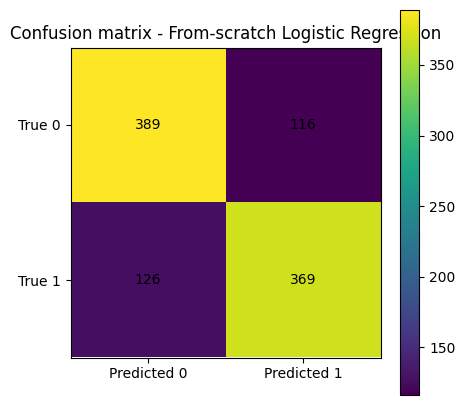

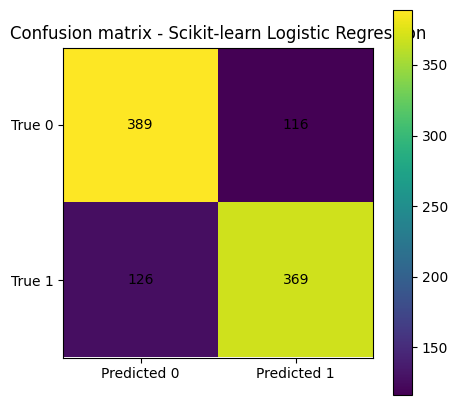

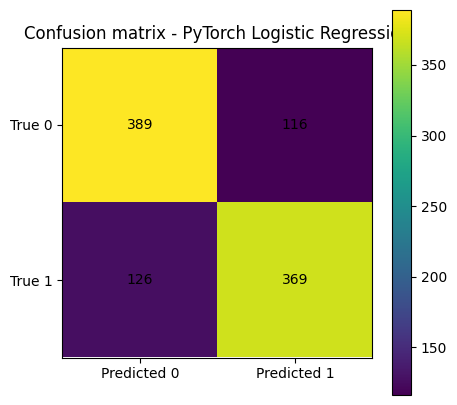

In [277]:
cm_scratch = confusion_matrix(y_test, scratch_preds)
cm_sklearn = confusion_matrix(y_test, sklearn_preds)
cm_torch = confusion_matrix(y_test, torch_preds)

plot_confusion_matrix(
    cm_scratch,
    [0,1],
    "Confusion matrix - From-scratch Logistic Regression"
)

plot_confusion_matrix(
    cm_sklearn,
    [0,1],
    "Confusion matrix - Scikit-learn Logistic Regression"
)

plot_confusion_matrix(
    cm_torch,
    [0,1],
    "Confusion matrix - PyTorch Logistic Regression"
)

#### Hyperparameter Sweep

##### Learning Rate
Looking at the accuracy and at the ROC-AUC vs. the learning rate, we can clearly distinguish three regimes:
- *`1e-5 - 1e-3` - `lr` too small*: the optimizer converges very slowly, so after 1000 iterations it has not reached the optimum yet. This leads to a lower ROC-AUC score and accuracy, while the loss stays higher.
- *`1e-2 - 1` - intermediate `lr`*: this is the good region. The optimum is reached within the allotted iterations, updates are large enough to move efficiently but not large enough to destabilize optimization. This shows through a plateau in ROC-AUC and accuracy
- *`~3+` - `lr` too big*: the optimizer overshoots the minimum repeatedly. This is clearly shown in the loss curves, that after a small decrease start oscillating, and the oscillation amplitude grows with the `lr` value. The loss does not explode, so gradient descent does not lead to divergence, but it is unstable. Similarly to what we have seen in the 1D case for linear regression with `lr=1`, this means that the effective multiplier magnitude for the difference between the current weights and the optimum ones is $\gtrsim1$, although in this case the landscape is much more complicated.

It is relevant to note that the instability threshold is much greater than in the linear regression case ($\sim3$ instead of $\sim1$), because logistic regression does not have the same quadratic loss geometry as linear regression, and also applying binary cross-entropy + sigmoid changes gradient magnitudes substantially. The threshold is problem-dependent.

Also, it is notable how ROC-AUC changes smoothly, while accuracy more abruptly. This is a consequence of the fact that ROC-AUC uses probabilities and ranking, while accuracy uses hard thresholds. This makes ROC-AUC often the more informative metric during optimization studies.

In [278]:
lr_values = np.logspace(-5, 1, 80)
sweep_results, loss_curves = parameter_sweep_classification(
    model_cls=LogisticRegression, 
    param_grid={
        'lr': lr_values
    }, 
    X_train=X_train_scaled, 
    y_train=y_train, 
    X_test=X_test_scaled, 
    y_test=y_test, 
    base_params={'n_iters':1000})
sweep_df = pd.DataFrame(sweep_results)

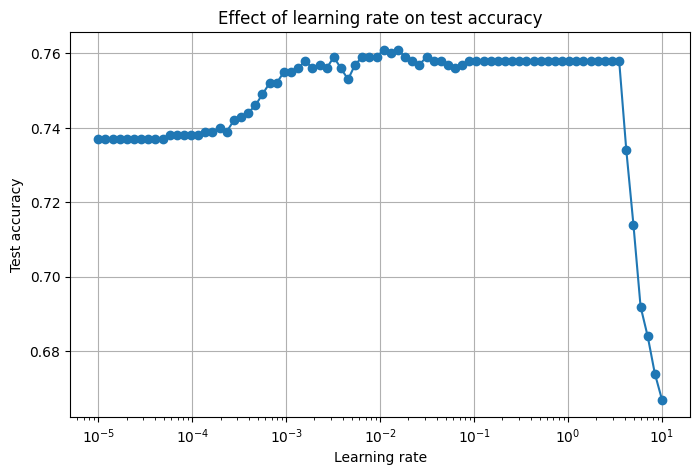

In [279]:
plt.figure(figsize=(8, 5))
plt.plot(sweep_df["lr"], sweep_df["test_accuracy"], marker="o")
plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("Test accuracy")
plt.title("Effect of learning rate on test accuracy")
plt.grid(True)
plt.show()

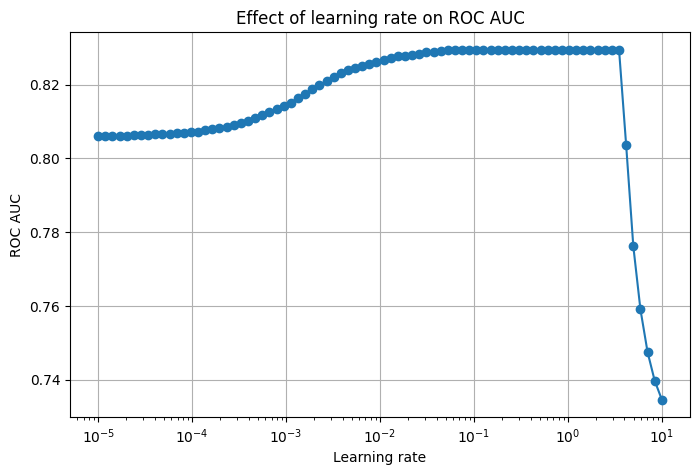

In [280]:
plt.figure(figsize=(8, 5))

plt.plot(sweep_df["lr"], sweep_df["test_roc_auc"], marker="o")

plt.xscale("log")

plt.xlabel("Learning rate")
plt.ylabel("ROC AUC")
plt.title("Effect of learning rate on ROC AUC")

plt.grid(True)
plt.show()

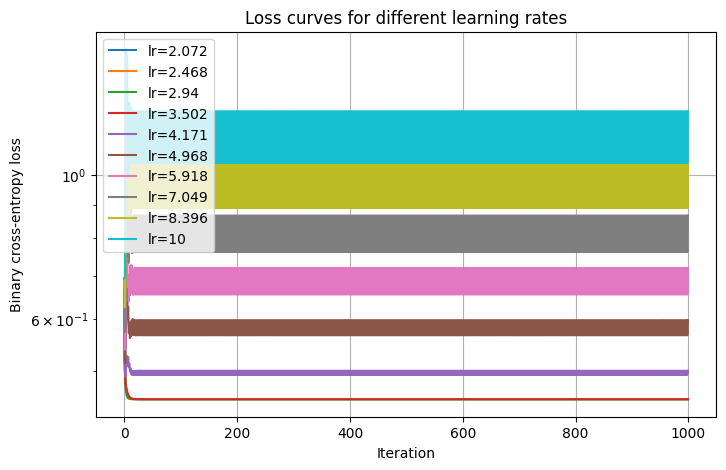

In [281]:
plt.figure(figsize=(8, 5))

for item in loss_curves[-10:]:
    loss = np.asarray(item["loss"])

    valid_mask = np.isfinite(loss)

    plt.plot(
        np.arange(len(loss))[valid_mask],
        loss[valid_mask],
        label=f"lr={item['lr']:.4g}",
    )

plt.xlabel("Iteration")
plt.ylabel("Binary cross-entropy loss")
plt.title("Loss curves for different learning rates")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.show()

##### Threshold
It is obvious that a higher thresholds corresponds to fewer positive predictions, so the precision increases with the threshold, while the recall decreases.

F1 score has a clear optimum, most likely at the $0.5$ threshold.

Accuracy is comparatively flat, meaning that all the thresholds considered produce a similar classification count, even though the number of false positive vs. false negatives changes substantially. This is another demonstration that accuracy hides a lot of information.

In [282]:
thresholds = np.linspace(0.0, 0.99, 99)
sweep_results, loss_curves = parameter_sweep_classification(
    model_cls=LogisticRegression, 
    param_grid={
        'threshold': thresholds
    }, 
    X_train=X_train_scaled, 
    y_train=y_train, 
    X_test=X_test_scaled, 
    y_test=y_test, 
    base_params={'n_iters':1000, 'lr':0.01})
threshold_df = pd.DataFrame(sweep_results)

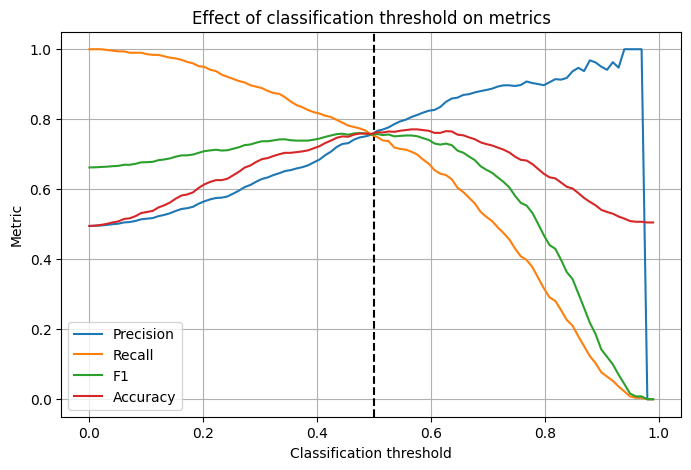

In [283]:
plt.figure(figsize=(8, 5))

plt.axvline(0.5, ymin=0., ymax=1, ls='--', c='k')
plt.plot(threshold_df["threshold"], threshold_df["test_precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["test_recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["test_f1"], label="F1")
plt.plot(threshold_df["threshold"], threshold_df["test_accuracy"], label="Accuracy")

plt.xlabel("Classification threshold")
plt.ylabel("Metric")
plt.title("Effect of classification threshold on metrics")
plt.legend()
plt.grid(True)

plt.show()

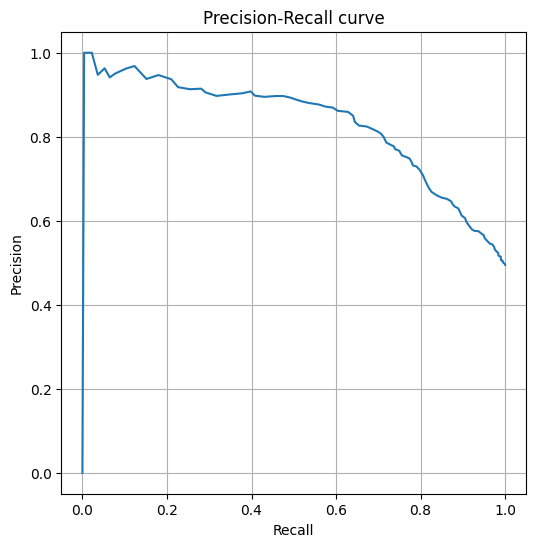

In [284]:
plt.figure(figsize=(6, 6))

plt.plot(
    threshold_df["test_recall"],
    threshold_df["test_precision"],
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve")

plt.grid(True)
plt.show()

##### Learning Rate $\times$ Threshold
From this plot, we can learn several things:
- the bright yellow plateau means that there are many `(lr, threshold)` pairs that produce near-optimal F1 -> the model is robust, and not hypersensitive to tiny hyperparameter changes
- When the learning rate is low (`log10(lr) < -3`), the model is undertrained, so the probabilities are underseparated. This makes the threshold matter more, and the sharp transition around `threshold ≈ 0.5` is expected when the classifier output is concentrated near 0.5
- High thresholds kill the F1 score. In this region, though precision may still be high, recall collapses, thus the F1 score collapses as well -> aggressive thresholds are dangerous in balanced optimization settings
- Intermediate learning rates (`lr ≈ 1e-2 to 1e-1`) maximize flexibility, meaning that at this point the optimization converges sufficiently, so the probabilities become well calibrated/separated, and threshold tuning becomes effective

In [285]:
lr_values = np.logspace(-5, 1, 50)
threshold_values = np.linspace(0.01, 0.99, 50)

heatmap_results, loss_curves = learning_rate_threshold_sweep(
    model_cls=LogisticRegression,
    lr_values=lr_values,
    threshold_values=threshold_values,
    X_train=X_train_scaled,
    y_train=y_train,
    X_test=X_test_scaled,
    y_test=y_test,
    base_params=None,
)

heatmap_df = pd.DataFrame(heatmap_results)

f1_matrix = heatmap_df.pivot(
    index="lr",
    columns="threshold",
    values="test_f1"
)

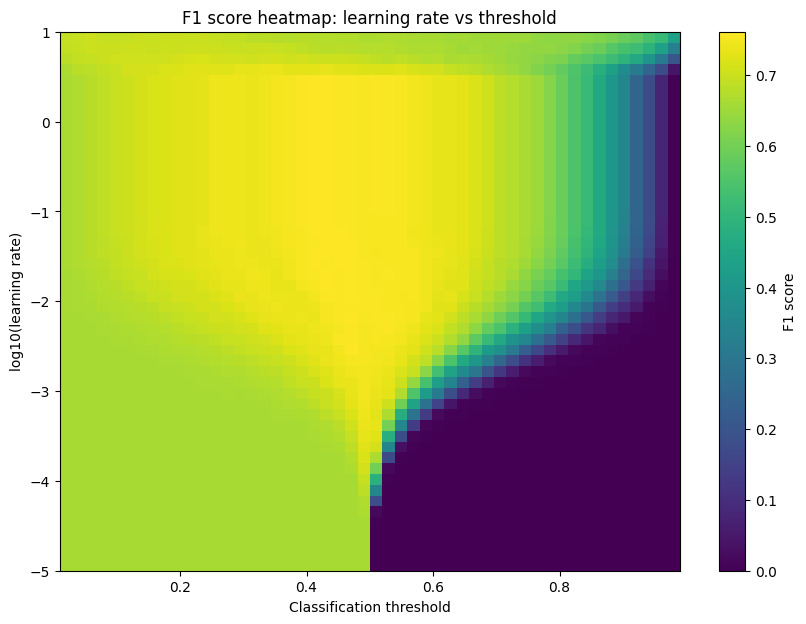

In [286]:
plt.figure(figsize=(10, 7))

plt.imshow(
    f1_matrix.values,
    aspect="auto",
    origin="lower",
    extent=[
        threshold_values.min(),
        threshold_values.max(),
        np.log10(lr_values.min()),
        np.log10(lr_values.max()),
    ],
)

plt.colorbar(label="F1 score")

plt.xlabel("Classification threshold")
plt.ylabel("log10(learning rate)")
plt.title("F1 score heatmap: learning rate vs threshold")

plt.show()

In [287]:
best_row = heatmap_df.loc[heatmap_df["test_f1"].idxmax()]
best_row

lr                    0.015264
threshold                 0.47
test_accuracy             0.76
test_precision        0.749511
test_recall           0.773737
test_f1               0.761431
test_roc_auc          0.827799
fit_time              0.223034
initial_train_loss    0.693147
final_train_loss       0.45742
min_train_loss         0.45742
stable                    True
converged                 True
Name: 1323, dtype: object